# Makemore 4：成为反向传播忍者

[视频](https://www.youtube.com/watch?v=q8SA3rM6ckI)<br>
[代码仓库](https://github.com/karpathy/makemore)<br>
[Eureka Labs Discord](https://discord.com/invite/3zy8kqD9Cp)

## 目录

- [为什么我们应该如此关注反向传播？](#为什么我们应该如此关注反向传播)
    - [示例 - 深度片段嵌入用于双向图像-句子映射](#示例---深度片段嵌入用于双向图像-句子映射)
- [练习 1 - 反向传播](#练习-1---反向传播)
    - [1 - Logprobs](#1---logprobs)
    - [2 - Probs](#2---probs)
    - [3 - Counts_Sum_Inv](#3---counts_sum_inv)
    - [5.1 - Counts](#51---counts)
    - [4 - Counts_Sum](#4---counts_sum)
    - [5.2 - Counts](#52---counts)
    - [6 - Norm_Logits](#6---norm_logits)
    - [7 - Logit_Maxes](#7---logit_maxes)
    - [8 - Logits](#8---logits)
    - [9 - h、W2 和 b2（线性层的反向传播）](#9---h-w2-和-b2线性层的反向传播)
    - [10 - hpreact](#10---hpreact)
    - [11 - bngain、bnraw、bnbias](#11---bngainbnrawbnbias)
    - [12 - bndiff、bnvar_inv（批归一化层）](#12---bndiffbnvar_inv批归一化层)
    - [13 - bnvar](#13---bnvar)
    - [贝塞尔校正](#贝塞尔校正)
    - [14 - bndiff2](#14---bndiff2)
    - [15 - bndiff](#15---bndiff)
    - [16 - bnmeani](#16---bnmeani)
    - [17 - hprebn](#17---hprebn)
    - [18 - embcat、W1、b1（线性层）](#18---embcatw1b1线性层)
    - [19 - emb](#19---emb)
    - [20 - C](#20---c)
- [练习 2 - 简化损失函数](#练习-2---简化损失函数)
    - [插曲：dlogits 是什么？](#插曲dlogits-是什么)
- [练习 3 - 简化批归一化](#练习-3---简化批归一化)
    - [步骤 1](#步骤-1)
    - [步骤 2](#步骤-2)
    - [步骤 3](#步骤-3)
    - [步骤 4](#步骤-4)

## 为什么我们应该如此关注反向传播？

[你应该花时间*真正*理解反向传播。](https://karpathy.medium.com/yes-you-should-understand-backprop-e2f06eab496b)<br>

在过去两讲中，我们构建了一个相当扎实的多层感知机（MLP）来生成更多名字。<br>
我们这样做是因为在[第一讲 makemore](../N002%20-%20Makemore%201/N002%20-%20Makemore.ipynb)中，我们发现直接的二元语法模型不足以捕捉数据的复杂性。MLP 方法可以非常灵活地实现基于 [\[Bengio et al. 2003\]](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf) 的更强大的三元语法方法。

我们了解 MLP 的架构及其工作原理。训练的一个关键部分是 `loss.backward()` 调用，它触发 PyTorch 的反向传播（backpropagation）例程来计算梯度（gradient），最终用于改进模型参数。**我们还没有探索这实际上是如何工作的。**

我们已经使用 [Micrograd](../N001%20-%20Building%20Micrograd/N001%20-%20Micrograd.ipynb) 简单探索过反向传播，但*仅限于标量值*。<br>
**要真正理解反向传播，我们现在需要将其从标量扩展到张量（tensor）。**

最好的探索方式是**从零开始，用 PyTorch 为基于张量的 Makemore-MLP 实现我们自己的反向传播。**

> 反向传播的主要问题在于，[**它是一种有漏洞的抽象。**](https://karpathy.medium.com/yes-you-should-understand-backprop-e2f06eab496b)

反向传播并不是一种*以某种方式*为我们的 MLP 提供最佳梯度的操作。<br>
假设它是某种黑魔法，可以让我们抽象掉学习过程中的所有复杂性和挑战，<br>
这是搬起石头砸自己脚的好方法。

> 确切了解反向传播的工作原理以及如何调试它是一个*巨大的优势*。

如果对反向传播没有扎实的理解，微妙的错误可能会悄悄出现并严重影响性能。<br>
**我们绝不应该仅仅因为 PyTorch 包含自动微分（autograd）来替我们处理这些细节，就跳过反向传播的细节。**

<img src="./img/memelol.png" alt="理解反向传播在不同时期的角色" width="500"/>

### 示例 - 用神经网络降低数据维度

Geoff Hinton 和 Ruslan Salakhutdinov 的 [2006 年论文](http://www.cs.toronto.edu/~hinton/absps/science.pdf) 展示了深度神经网络如何以可学习的方式应用于降低数据维度。<br>
这篇论文实际上引入了受限玻尔兹曼机，其结构与今天的自编码器非常相似。如果你不知道那是什么，不用担心。该论文的代码库是用 MATLAB 编写的，可以在[这里](https://code.google.com/archive/p/matrbm/)找到。

早期的多层感知机（MLP）并不是使用 Tensorflow 或 PyTorch 等框架，甚至不是用 Python 编程语言实现的。<br>
当时*没有* GPU 加速，*没有*自动微分，*没有*用于层或优化器的高级抽象。<br>
相反，当时的网络主要用 MATLAB 实现，**全部手工完成**。

### 示例 - 深度片段嵌入用于双向图像-句子映射

[Karpathy 及其同事 2014 年的这篇论文](https://arxiv.org/abs/1406.5679) 是用 Python 实现的，但只使用了 NumPy。<br>
代价函数、激活函数（activation function）和反向传播都是作者自己完整实现的。

**题外话 - 论文简要概述：**<br>
该论文涵盖了在一组图像及其相关自然语言描述上训练模型的过程，以便之后可以给定一张图像指定一组固定的保留句子，反之亦然。这被称为*多模态学习*。论文的设置使模型能够学习描述和图像之间的联系。

**好了，现在让我们进入反向传播的细节。**<br>
我们将首先设置并实现[上一讲](../N004%20-%20Makemore%203%20-%20Activations,%20BatchNorm/N004%20-%20Makemore_3.ipynb)中 MLP 的前向传播。

In [ ]:
# There's no change in the first several cells compared to last lecture
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Read in all the words
words = open('../names.txt', 'r').read().splitlines()
print('Samples:', words[:8])
print('Size:', len(words))
print('Largest:', max(len(w) for w in words))

Samples: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Size: 32033
Largest: 15


In [ ]:
# Build a vocabulary of characters and map them to integers
chars = sorted(list(set(''.join(words))))  # set(): Throwing out letter duplicates

stoi = {s:i+1 for i,s in enumerate(chars)} # Make tuples of type (char, counter)
stoi['.'] = 0                              # Add this special symbol's entry explicitly
itos = {i:s for s,i in stoi.items()}       # Switch order of (char, counter) to (counter, char)

vocab_size = len(itos)

# Showing the two mappings, they really just are mirrors of one another
print(itos)
print(stoi)
print('Training vocabulary size:', vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
Training vocabulary size: 27


我们再次以这样的方式构建数据集：`X` 中的输入是字符三元组，`Y` 中的目标是下一个字符。<br>
我们将使用与之前相同的架构：嵌入（embedding）层、线性层、批归一化（BatchNorm）、非线性激活和最终的线性层来产生下一个字符预测的 logits。<br>
我们还将使用相同的损失函数——交叉熵（cross-entropy）损失。

In [ ]:
# Build the dataset
block_size = 3 # Context length: Amount of characters used to predict the next one

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # Crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

random.seed(42)

# Shuffling and dividing into three (!) subsets
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])   # 80% train
Xdev, Ydev = build_dataset(words[n1:n2]) # 10% development
Xte,  Yte  = build_dataset(words[n2:])   # 10% test

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


**好的，模板部分完成。现在进入正题。**<br>
为了学习如何计算梯度，我们将利用 PyTorch 通过新函数 `cmp()` 进行比较：

In [ ]:
# Utility function we will use later 
# when comparing manually calculated gradients with PyTorch's calculated gradients

# s  is a string describing the tensor
# dt is the manually calculated gradient
# t  is the tensor PyTorch calculates the gradient for
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()        # Exact match (no difference)
  app = torch.allclose(dt, t.grad)           # Approximate match (close enough)
  maxdiff = (dt - t.grad).abs().max().item() # Maximum difference between the two -> should be zero
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

现在我们将像之前一样布置 MLP 的架构。<br>
注意许多参数（如偏置）是以非标准方式初始化的。<br>
这是因为有时用全零初始化（如我们之前所做的）可能会*掩盖*不正确的反向传播实现。<br>
通过添加 `0.1` 作为因子，会产生一些参数表达性，使错误的实现更容易被发现。

**此时只需记住：**<br>
MLP 接收一个包含 $ 个 token 化字母的上下文，并提供 7$ 个可能输出 token 中的一个，代表最可能跟在 $ 个字母输入后面的字母。

In [ ]:
n_embd = 10   # Dimensionality of the NN's character embedding vectors
n_hidden = 64 # Number of neurons per MLP's hidden layer

g = torch.Generator().manual_seed(2147483647)       # For reproducibility
C  = torch.randn((vocab_size, n_embd), generator=g) # Character embedding table

prop_scale = 0.1 # Adding the scaling factor to avoid masking potential errors in backward pass

# Layer 1
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) # (3x10)x64
W1 *= (5/3)/((n_embd * block_size)**0.5)              # Initial Weight scaling
b1 = torch.randn(n_hidden, generator=g) * prop_scale  # Using 64 biases b1 for fun, not really needed

# Batch-Normalization
bngain = torch.randn((1, n_hidden))*prop_scale + 1.0
bnbias = torch.randn((1, n_hidden))*prop_scale

# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * prop_scale # 64x27
b2 = torch.randn(vocab_size, generator=g) * prop_scale # These biases are needed, unlike b1, to unmask potential, minute calculation errors for the gradients

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # Total number of parameters

for p in parameters:
  p.requires_grad = True

4137


权重和偏置矩阵被初始化为小的、随机的但具有表达性的值。<br>
和之前一样，我们将使用批处理输入。批量大小设为 2$。<br>
**在下面的情况下，我们只构建一个这样的批次。**

一个批次通过我们的网络进行前向传播就足够了：

In [ ]:
# Constructing a batch from the training set
batch_size = 32 # How many examples we will process at once
n = batch_size  # N as shorter variable also, for convenience

# Construct the minibatch itself
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) # Random indices
Xb, Yb = Xtr[ix], Ytr[ix] # Construct the randomly assembled batch from Xtr,Ytr

**现在我们将批次通过网络。**<br><br>
这个前向传播，特别是批归一化和交叉熵损失，被重写为 PyTorch 实现的逐步版本，<br>
以便我们可以手动进行反向传播：

In [ ]:
# Forward pass, "chunked" into smaller, individual steps that are possible to 'backward' one at a time

emb = C[Xb]                         # Embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors, form a large one

# Linear layer 1
hprebn = embcat @ W1 + b1           # Hidden layer pre-activation

# BatchNorm layer
bnmeani = 1/n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1 / (n-1) * (bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

# Non-linearity
h = torch.tanh(hpreact) # hidden layer

# Linear layer 2
logits = h @ W2 + b2 # output layer

# Cross entropy loss (all this was previously condensed within F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # Subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # If (1.0 / counts_sum) was used instead: Can't get backprop to be bit exact
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None # Zero out all gradients, clear from residuals from previous backward passes

# Retain gradients, they won't be freed after the backward pass finishes so we can compare
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()

loss.backward()
loss

tensor(3.3344, grad_fn=<NegBackward0>)

好的，我们构建了 MLP，创建了一个批次，并将其通过网络。<br>
我们告诉网络为所有中间张量保留梯度。<br>
然后我们运行 PyTorch 的 `loss.backward()` 来自动计算所有这些梯度。

我们前向传播的变量以下列方式相互连接形成 `loss`：<br>
![反向传播计算图](./img/ninja_graph.png)

上面的依赖和操作图不太美观，所以我们将在接下来的几个部分中逐步讲解。<br>
**我们现在有了可供参考的梯度。**<br>
**现在由我们来构建并比较我们自己的反向传播实现。**

## 练习 1 - 反向传播
**手动反向传播整个前向传播，按照上面定义的顺序逐一处理所有变量，从后向前。**

In [ ]:
# Just as a reminder, from Micrograd we know:
#
# Gradients of sum c = a + b:
# a.grad = c.grad * (1)
# b.grad = c.grad * (1)
#
# Gradients of multiplication c = a * b:
# a.grad = c.grad * b.data
# b.grad = c.grad * a.data

### 1 - Logprobs

`loss` 直接且仅依赖于通过 `loss = -logprobs[range(n), Yb].mean()` 对 `logprobs` 的操作。<br>
<br>
由于梯度与计算它们的变量具有相同的形状，`dlogprobs` 的形状也必须是 `(32, 27)`，就像 `logprobs` 一样。<br>
通过 `-logprobs[range(n), Yb]`，我们取每行 $i\in [0;n)$ 中 `Yb` 对应条目所指定的索引处的值。<br>
这些且仅这些特定索引构成了我们计算负均值的基础。<br>
<br>
对于梯度计算，这意味着我们仅通过逐行"取出"的索引来影响 `loss`。<br>
**`logprobs` 中未被 `[range(n), Yb]` 选定的所有值的梯度为零。我们可以直接这样说，因为这些值不影响 `loss`。**

三个值 $a,\ b,\ c$ 的负均值是 $(-\frac{a+b+c}{3}) = (-\frac{1}{3}) \cdot a + (-\frac{1}{3}) \cdot b + (-\frac{1}{3}) \cdot c$。<br>
我们可以推断 $\frac{\partial (-mean)}{\partial a} = \frac{\partial (-mean)}{\partial b} = \frac{\partial (-mean)}{\partial c} = -\frac{1}{3}$。

$$\frac{\partial\ \text{loss}}{\partial\ \text{logprobs}} = \underline{\underline{-\frac{1}{n}}}$$

**`logprobs` 中所有被选中的值的梯度为 $-\frac{1}{n}$，其中 $n$ 是 `range(n)` 调用中的行数，"取出"了索引：**

In [ ]:
# LOGPROBS
dlogprobs = torch.zeros_like(logprobs) # (32x27), all zeros, shaped just like logprobs (this implies none participate in loss, but we will fix that next)
dlogprobs[range(n), Yb] = -1.0 / n     # (32x27), only the correct indices get -1/n as gradient attributed to them (the rest remains 0)
cmp('logprobs', dlogprobs, logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


### 2 - Probs

`probs` 直接且仅用于通过 `logprobs = probs.log()` 计算 `logprobs`，正式地这意味着 $\log_e(probs)$。<br>
**我们在这里需要小心，不要忘记一个额外的步骤。**<br>
<br>
由于 `probs` 对 `logprobs` 起作用，**相应的梯度 `dlogprobs` 通过链式法则对 `dprobs` 起作用：**
$$d\text{probs} = \frac{d \log_e(\text{probs})}{d \text{probs}} \cdot d\text{logprobs}$$

我们还应该看看 `logprobs` 和 `probs` 的形状，但这里没有什么可担心的。<br>
两者都是 `(32, 27)`。$\log_e(\text{probs})$ 对 $\text{probs}$ 的导数是：
$$\frac{d \log_e(\text{probs})}{d\text{probs}} = \frac{1}{\text{probs}}$$

因此，与 `dlogprobs` 进行乘法链式运算，我们得到：
$$d\text{probs} = \frac{1}{\text{probs}} \cdot d\text{logprobs}$$

在代码中实现如下：

In [ ]:
# PROBS
dprobs = (1 / probs) * dlogprobs # (32x27), elementwise multiplication
cmp('probs', dprobs, probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


### 3 - Counts_Sum_Inv

`counts_sum_inv` 只在一个地方使用：`probs = counts * counts_sum_inv`。<br>
<br>
`counts_sum_inv` 只有 `probs` 依赖于它，但它与 `counts` 交互来计算 `probs`。<br>
因为两者相互交互，`counts_sum_inv` 和 `counts` 的梯度是相互依赖的。

`counts` 是一个 `(32, 27)` 矩阵。<br>
`counts_sum_inv` 是一个 `(32, 1)` 向量。<br>
对于乘法，PyTorch 将向量 `counts_sum_inv` 广播到 `counts` 的列上，形成一个同样大小的 `(32, 27)` 矩阵。<br>
利用链式法则的知识，我们可以计算 `counts_sum_inv` 关于导致它的*两个*操作——广播和乘法的梯度。

对于乘法部分，我们得到：
$$\frac{\partial (\text{counts} \cdot \text{counts\_sum\_inv})}{\partial \text{counts\_sum\_inv}} = \text{counts} \cdot \text{dprobs}$$
由于链式法则，`dprobs` 与 `counts` 相乘。

**我们需要对广播部分应用一些直觉。**<br>
从 [micrograd 讲座](../N001%20-%20Building%20Micrograd/N001%20-%20Micrograd.ipynb) 我们知道，如果一个值在多个地方使用，梯度会在这些多个使用点上求和。<br>
如果 `counts_sum_inv` 被广播到 `counts` 的所有列上，`counts_sum_inv` 的梯度会在第一步结果的所有列上求和：
$$\frac{\partial\ \text{probs}}{\partial\ \text{counts\_sum\_inv}} = \sum_i \left( \text{counts} \cdot \text{dprobs} \right)_{:,i}$$

可以这样实现：

In [ ]:
# COUNTS_SUM_INV
# probs = counts * counts_sum_inv (counts = 32x27, counts_sum_inv = 32x1) or
# c = a * b, but with tensors
# a[3x3] * b[3x1] ---->
# a11*b1 a12*b1 a13*b1
# a21*b2 a22*b2 a23*b2
# a31*b3 a32*b3 a33*b3
# ----> c[3x3]

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # (32x1), sum over the rows (axis 1, the columns, keepdim=True to retain 2D shape)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv) # true

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


### 5.1 - Counts

正如我们所看到的，`probs` 是使用 `counts` 计算的。<br>

`counts` 有两个变量依赖于它：
- `probs` 通过 `probs = counts * counts_sum_inv`
- `counts_sum_inv` 通过 `counts_sum = counts.sum(1, keepdims=True)`（以及 `counts_sum_inv = counts_sum**-1`）

**`counts` 是一个被使用两次的节点，一次用于 `probs`，一次用于 `counts_sum_inv`。**

这两条计算路径都会影响 `counts` 的梯度，但在这一点上，我们只覆盖了 `probs` 路径，还没有处理 `dcounts_sum`。

`counts` 的形状是 `(32, 27)`。<br>
`counts_sum_inv` 的形状是 `(32, 1)`。<br>
我们可以直接应用乘法的梯度计算规则：$c = a \cdot b$ 时 $\frac{\partial c}{\partial a}$ 是 $b$。

另外，我们不能忘记链式法则：

In [ ]:
# Step 1:
dcounts = counts_sum_inv * dprobs # (32x1) * (32x27) = (32x27), elementwise multiplication (broadcasting automatically)

# Step 2:
# Left undone for now
cmp('counts', dcounts, counts) # False, but to be fixed later down the line

counts          | exact: False | approximate: False | maxdiff: 0.0057856254279613495


**这不起作用，因为它只覆盖了 `counts` 影响损失的两条路径中的一条。**<br>
我们将在下一步计算 `dcounts_sum` 之后回来处理 `dcounts`。

### 4 - Counts_Sum

`counts_sum` 用于通过 `counts_sum_inv = counts_sum**-1` 计算 `counts_sum_inv`。<br>
由于这是它唯一的用途，我们可以直接计算 `counts_sum_inv` 关于 `loss` 的偏导数。<br>

应用链式法则后，这变为：

In [14]:
# COUNTS_SUM
dcounts_sum = -counts_sum**(-2) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


### 5.2 - Counts

我们现在可以通过 `counts_sum = counts.sum(1, keepdims=True)` 处理 counts 的第二个用法。<br>
- `counts` 的形状是 `(32, 27)`
- `counts_sum` 的形状是 `(32, 1)`

我们执行这个操作：

$$\begin{bmatrix}
a_{11} + a_{12} + a_{13}\ \
a_{21} + a_{22} + a_{23}\ \
a_{31} + a_{32} + a_{33}\ \
\end{bmatrix} = \begin{bmatrix}
b_1\ \
b_2\ \
b_3\ \
\end{bmatrix}$$

`b`（`counts_sum` 向量）如何依赖于 `a`（`counts` 矩阵）？<br><br>
仅看 $b_1$，它只依赖于 $a_{11}$、$a_{12}$ 和 $a_{13}$。所有其他 $a$ 相对于 $b_1$ 的梯度为零。<br>
$a_{11}$、$a_{12}$ 和 $a_{13}$ 的梯度是 $1.0$。<br>
（偏导数 $\frac{\partial b_1}{\partial a_{11}}$ 是 $1.0$）

在链式法则中，我们有局部导数乘以 $b_1$ 的导数。因为局部导数是 $1.0$，我们可以省略它，它就是 $b_1$。<br>
$b_1$ 的导数将均匀地流向所有用于计算它的 $a$。这等同于说 $b_1$ 的导数是 $1.0$。<br><br>
从链式法则中，我们知道 `dcounts_sum`。<br><br>
因为所有局部导数都是 1，我们只需要在 `counts` 的每一行中复制 `dcounts_sum` 的内容，从而将其扩展到 `counts` 的形状。<br>
此外，请记住，这是 `counts_sum_inv` 关于 `loss` 的偏导数的第二步。<br>
所以，我们需要做的是用 `+=` 添加到 `dcounts` 现有的一半中。

In [15]:
# COUNTS

# a11 a12 a13 ---> b1 (= a11 + a12 + a13)
# a21 a22 a23 ---> b2 (= a21 + a22 + a23)
# a31 a32 a33 ---> b3 (= a31 + a32 + a33)

dcounts += torch.ones_like(counts) * dcounts_sum # (32x27), all ones, multiplied by (32x1) = (32x27) (broadcasting automatically)
cmp('counts', dcounts, counts)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


### 6 - Norm_Logits

`norm_logits` 用于通过 `counts = norm_logits.exp()` 计算 `counts`。<br>
$e^x$ 的局部导数是 $e^x$，由于我们声明 `counts = norm_logits.exp()`，我们可以直接使用 `counts` 作为局部导数：

In [16]:
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


### 7 - Logit_Maxes

`logits` 和 `norm_logits` 用于通过 `norm_logits = logits - logit_maxes` 计算 `norm_logits`。<br>
`norm_logits` 是 `(32, 27)`，`logits` 也是，但 `logit_maxes` 是 `(32, 1)`。

我们基本上执行这个操作：

$$\begin{bmatrix}
c_{11} & c_{12} & c_{13}\ \
c_{21} & c_{22} & c_{23}\ \
c_{31} & c_{32} & c_{33}\ \
\end{bmatrix} = \begin{bmatrix}
a_{11} & a_{12} & a_{13}\ \
a_{21} & a_{22} & a_{23}\ \
a_{31} & a_{32} & a_{33}\ \
\end{bmatrix} - \begin{bmatrix}
b_{1} & b_1 & b_1\ \
b_{2} & b_2 & b_2\ \
b_{3} & b_3 & b_3\ \
\end{bmatrix}$$
$$例如\ c_{32} = a_{32} - b_3$$

我们必须看看每个 `c` 是如何产生的。<br><br>
每个 `c` 是一个 `a` 和某个 `-b` 的和。<br>
每个 `c` 相对于其关联 `a` 的导数是 `1`。<br>
每个 `c` 相对于其关联 `b` 的导数是 `-1`。

换句话说，每个 `c` 中包含的导数已经均匀地流向相应的 `a`，同时也负向流向 `b`。<br>
这意味着 $dc = da$，即 $\text{dlogits} = \text{dnorm\_logits}$ 且 $\text{dlogit\_maxes} = -\text{dnorm\_logits}$。<br>
$\text{dlogit\_maxes}$ 已经完成了，$\text{dlogits}$ 只完成了部分。

In [17]:
dlogits = dnorm_logits.clone()
dlogit_maxes = -1 * dnorm_logits.sum(1, keepdim=True)

cmp('logit_maxes', dlogit_maxes, logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


### 8 - Logits

除了在 `norm_logits = logits - logit_maxes` 中的用法之外，`logits`（其形状为 `(32, 27)`）还在<br>
`logit_maxes = logits.max(1, keepdim=True).values` 中使用。

通过调用 `.max(1)`，PyTorch 不仅提供每行的最大值，还提供它们在 `logits` 中的相应索引，这对反向传播很有用。

导数在每个"取出"的位置应该是 $1$，在其他地方是 $0$。<br>
换句话说，我们需要将 `dlogit_maxes` 分散到 `dlogits` 中，并在最大值被"取出"的索引处添加它们的值。

In [18]:
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

# Getting the indices of row-wise logits.max and one-hot encoding it as one occurrence of class 'index' with 27 (logits.shape[1]) classes possible
# This results in (row-wise) setting 1 where value at index was 'plugged out' for max
# Multiplying with dlogit_maxes replaces the 1s with correct gradient values
# += for completing the second branch

cmp('logits', dlogits, logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


### 9 - h、W2 和 b2（线性层的反向传播）

`h` 只用于通过 `logits = h @ W2 + b2` 计算 `logits`。<br>
- `dlogits` 的形状是 `(32, 27)`
- `h` 是 `(32, 64)`
- `W2` 是 `(64, 27)`
- `b2` 是 `(27)`

我们如何计算 `h`、`W2`、`b2` 关于 `loss` 的偏导数？<br>
为了理解正在发生的事情，让我们看一个具体的、小的例子并写出来：

$$\begin{bmatrix}d_{11} & d_{12}\ \ d_{21} & d_{22}\ \ \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12}\ \ a_{21} & a_{22}\ \ \end{bmatrix} \cdot \begin{bmatrix} b_{11} & b_{12}\ \ b_{21} & b_{22}\ \ \end{bmatrix} + \begin{bmatrix} c_{1} & c_{2}\ \ c_{1} & c_{2}\ \ \end{bmatrix}$$
这等同于：
$$d_{11} = a_{11} \cdot b_{11} + a_{12} \cdot b_{21} + c_1\ \
d_{12} = a_{11} \cdot b_{12} + a_{12} \cdot b_{22} + c_2\ \
d_{21} = a_{21} \cdot b_{11} + a_{22} \cdot b_{21} + c_1\ \
d_{22} = a_{21} \cdot b_{12} + a_{22} \cdot b_{22} + c_2$$

有了 `dlogits`，$\frac{\partial L}{\partial d_{11}}$、$\frac{\partial L}{\partial d_{12}}$、$\frac{\partial L}{\partial d_{21}}$ 和 $\frac{\partial L}{\partial d_{22}}$ 是已知的。<br>
我们现在想要 `L` 关于 `h` 或在我们的例子中 `a` 的偏导数。

$$\frac{\partial L}{\partial a_{11}} = \frac{\partial L}{\partial d_{11}} \cdot b_{11} + \frac{\partial L}{\partial d_{12}} \cdot b_{12}$$
$$\frac{\partial L}{\partial a_{12}} = \frac{\partial L}{\partial d_{11}} \cdot b_{21} + \frac{\partial L}{\partial d_{12}} \cdot b_{22}$$
$$\frac{\partial L}{\partial a_{21}} = \frac{\partial L}{\partial d_{21}} \cdot b_{11} + \frac{\partial L}{\partial d_{22}} \cdot b_{12}$$
$$\frac{\partial L}{\partial a_{22}} = \frac{\partial L}{\partial d_{21}} \cdot b_{21} + \frac{\partial L}{\partial d_{22}} \cdot b_{22}$$
例如，$a_{11}$ 被用于计算 $d_{11}$ 和 $d_{12}$，所以对于 $\frac{\partial L}{\partial a_{11}}$ 我们需要将 $\frac{\partial L}{\partial d_{11}}$ 和 $\frac{\partial L}{\partial d_{12}}$ 分别与 $b_{11}$ 和 $b_{12}$ 相乘，以此类推。<br>
我们可以继续将其重写为矩阵乘法的形式：
$$\begin{bmatrix} \frac{\partial L}{\partial d_{11}} & \frac{\partial L}{\partial d_{12}}\ \ \frac{\partial L}{\partial d_{21}} & \frac{\partial L}{\partial d_{22}}\ \ \end{bmatrix} \cdot \begin{bmatrix} b_{11} & b_{21}\ \ b_{12} & b_{22}\ \ \end{bmatrix} = \begin{bmatrix} \frac{\partial L}{\partial a_{11}} & \frac{\partial L}{\partial a_{12}}\ \ \frac{\partial L}{\partial a_{21}} & \frac{\partial L}{\partial a_{22}}\ \ \end{bmatrix} = \frac{\partial L}{\partial d}\ \times\ b^T$$

如果我们退后一步对 `b` 做这个过程，我们得到：$\frac{\partial L}{\partial b} = a^T\ \times\ \frac{\partial L}{\partial d}$。<br>
对于 `c`，我们得到：$\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d} \cdot sum(0)$。<br>
（$sum(0)$ 表示对第一个维度求和，即列。）

> 矩阵乘法的反向传播是前向传播（矩阵乘法）的转置。

---

**还有另一种更直观的方式来理解这一点。**

让我们再看看维度：

原始计算是：`logits = h @ W2 + b2`
- `dlogits` 的形状是 `(32, 27)`
- `h` 是 `(32, 64)`
- `W2` 是 `(64, 27)`
- `b2` 是 `(27)`

`dh` 应该与 `h` 具有相同的形状，即 `(32, 64)`。<br>
`dh` 必须是某种涉及 `dlogits` 和 `W2` 的矩阵乘法。<br>
获得 `(32, 64)` 形状的唯一方法是将 `(32, 27)` 矩阵 `dlogits` 与 `(27, 64)` 的 `W2` 转置矩阵相乘。

考虑到这一切，我们可以继续计算所有必要的偏导数：

In [19]:
dh = dlogits @ W2.T
cmp('h', dh, h)

dW2 = h.T @ dlogits
cmp('W2', dW2, W2)

db2 = dlogits.sum(0)
cmp('b2', db2, b2)

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0


### 10 - hpreact

`hpreact` 只用于通过 `h = torch.tanh(hpreact)` 计算 `h`。<br>
从 [micrograd](../N001%20-%20Building%20Micrograd/N001%20-%20Micrograd.ipynb) 中，我们知道 `tanh` 的导数是：

1313a = 	anh(z) = rac{e^{2z} - 1}{e^{2z} + 1}1313
1313rac{\partial a}{\partial z} = 1 - a^2 = 1 - 	anh^2(z)1313

考虑到这一点和链式法则，`hpreact` 关于 `loss` 的偏导数是：

In [20]:
dhpreact = (1.0 - h ** 2) * dh
cmp('hpreact', dhpreact, hpreact)

hpreact         | exact: True  | approximate: True  | maxdiff: 0.0


### 11 - bngain、bnraw、bnbias

`bngain`、`bnraw` 和 `bnbias` 只用于通过 `hpreact = bngain * bnraw + bnbias` 计算 `hpreact`。<br>
（`bngain` 和 `bnbias` 用于批归一化）

- `hpreact` 的形状是 `(32, 64)`
- `bngain` 是 `(1, 64)`
- `bnraw` 是 `(32, 64)`
- `bnbias` 是 `(1, 64)`

我们必须确保 PyTorch 的广播被正确地反向传播：

In [21]:
dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # Sum takes care of the broadcasting effects
cmp('bngain', dbngain, bngain)

dbnraw = bngain * dhpreact
cmp('bnraw', dbnraw, bnraw)

dbnbias = dhpreact.sum(0, keepdim=True) # Sum takes care of the broadcasting effects
cmp('bnbias', dbnbias, bnbias)

bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0


### 12 - bndiff、bnvar_inv（批归一化层）

`bndiff` 和 `bnvar_inv` 只用于通过 `bnraw = bndiff * bnvar_inv` 计算 `bnraw`。<br>
（`bndiff` 和 `bnvar_inv` 用于批归一化）

- `bndiff` 的形状是 `(32, 64)`
- `bnvar_inv` 是 `(1, 64)`
- `bnraw` 是 `(32, 64)`

考虑到广播，这相对简单直接：

In [22]:
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True) # Sum takes care of the broadcasting effects
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

# Step 1
dbndiff = bnvar_inv * dbnraw
cmp('bndiff', dbndiff, bndiff) # False, but to be fixed later down the line

bnvar_inv       | exact: True  | approximate: True  | maxdiff: 0.0
bndiff          | exact: False | approximate: False | maxdiff: 0.0011395297478884459


### 13 - bnvar

`bnvar` 只用于通过 `bnvar_inv = (bnvar + 1e-5) ** -0.5` 计算 `bnvar_inv`。<br>
（`bnvar` 和 `bnvar_inv` 用于批归一化）

由于我们在这里进行幂运算，我们想对导数应用幂法则：

1313rac{d}{dx}x^n=n \cdot x^{n-1}1313

In [23]:
dbnvar = (-0.5 * (bnvar + 1e-5) ** (-1.5)) * dbnvar_inv
cmp('bnvar', dbnvar, bnvar)

bnvar           | exact: True  | approximate: True  | maxdiff: 0.0


### 贝塞尔校正

在我们对 `bndiff2` 的用法进行反向传播之前——`bnvar = 1 / (n-1) * (bndiff2).sum(0, keepdim=True)`，我们需要理解其中应用的[贝塞尔校正（Bessel"s correction）](https://mathcenter.oxford.emory.edu/site/math117/besselCorrection/)。<br>
贝塞尔校正很有趣，因为这偏离了原始的批归一化论文，<br>
论文提出：$\sigma^2_B \leftarrow \frac{1}{m}\sum_{i=1}^{m}(x_i-\mu_B)^2$ 作为我们的方程。

我们使用 `n`，即论文中的 `m`，但然后从中减去 `1`。<br>
这是因为我们想使用样本所来自的总体方差的**无偏估计量**。<br>
它提供了总体方差更准确的估计。

*最初*，论文建议只在评估期间使用这个无偏估计量，而不是在训练期间。<br>
PyTorch 在训练期间也使用有偏估计量，但在评估期间使用无偏估计量。<br>
这在训练和评估之间引入了一个*可以避免的差异*，Andrej 在[这里](https://youtu.be/q8SA3rM6ckI?t=4051)指出了这一点。

有趣的是，随着批量大小的增加，出错的潜力会降低。*不过，这还是有点奇怪。*<br>
正如这里所做的，解决方案是在训练*和*评估期间都使用*无偏*估计量。

### 14 - bndiff2

`bndiff2` 只用于通过 `bnvar = 1 / (n-1) * (bndiff2).sum(0, keepdim=True)` 计算 `bnvar`。<br>
（`bndiff2` 和 `bnvar` 用于批归一化）

- `bndiff2` 是 $(32\times 64)$
- `bnvar` 是 $(1\times 64)$

> 对 `bndiff2` 列的求和在反向传播中变成了复制/广播。<br>
> 反之，如果我们在前向传播中有复制，这在反向传播中就变成了对同一维度的求和。

一个关于 `bndiff2` 和 `bnvar` 相互关系的示例：
$$\begin{bmatrix}a_{11} & a_{12}\ \ a_{21} & a_{22}\end{bmatrix} \rightarrow \begin{bmatrix}b_1\ \ b_2\end{bmatrix} = \begin{matrix}\frac{1}{(n-1)} \cdot (a_{11} + a_{21})\ \ \frac{1}{(n-1)} \cdot (a_{12} + a_{22})\end{matrix}$$

我们有 $b_1$ 和 $b_2$（即 `bnvar` 的列）的导数。<br>
我们想反向传播到 `a` 中。<br>
$\frac{b_1}{b_2}$ 的导数必须流经 $a$ 的第一/第二列，按 $\frac{1}{(n-1)}$ 缩放。<br><br>
结合链式法则，这给了我们以下结果：

In [24]:
dbndiff2 = (1.0 / (n-1)) * torch.ones_like(bndiff2) * dbnvar
cmp('bndiff2', dbndiff2, bndiff2)

bndiff2         | exact: True  | approximate: True  | maxdiff: 0.0


### 15 - bndiff

`bndiff` 在两个地方使用：
- `bndiff2 = bndiff**2`
- `bnraw = bndiff * bnvar_inv`

这使得计算 `dbndiff` *非常容易*。<br>
但我们必须记住，我们已经在步骤 2$ 中为 `dbndiff` 计算了第 $ 步。<br><br>
我们只需将两者相加：

In [25]:
# Step 2
dbndiff += 2 * bndiff * dbndiff2
cmp('bndiff', dbndiff, bndiff)

bndiff          | exact: True  | approximate: True  | maxdiff: 0.0


### 16 - bnmeani

`bnmeani` 只用于通过 `bndiff = hprebn - bnmeani` 计算 `bndiff`。

- `bnmeani` 的形状是 `(1, 64)`
- `bndiff` 是 `(32, 64)`
- `hprebn` 是 `(32, 64)`

这里发生了广播。这意味着 `bnmeani` 发生了变量重用。<br>
因此我们可以取 `dbndiff`，沿行求和并取反。<br>
`hprebn` 与 `bndiff` 形状相同，所以我们只需复制导数。

In [26]:
dbnmeani = (-1.0) * dbndiff.sum(0, keepdim=True)
cmp('bnmeani', dbnmeani, bnmeani)

# Step 1
dhprebn = dbndiff.clone() # Copy the tensor (not just the reference)
cmp('hprebn', dhprebn, hprebn) # False, but to be fixed later down the line

bnmeani         | exact: True  | approximate: True  | maxdiff: 0.0
hprebn          | exact: False | approximate: False | maxdiff: 0.0009513851255178452


### 17 - hprebn

如步骤 6$ 所见，`hprebn` 用于计算 `bndiff`。<br>
它的第二个用途是通过 `bnmeani = 1/n * hprebn.sum(0, keepdim=True)` 计算 `bnmeani`。<br>
- `hprebn` 的形状是 `(32, 64)`
- `bnmeani` 是 `(1, 64)`

这是广播的相反操作。我们必须将 `bnmeani` 的导数乘以 `1/n` 复制到 `hprebn` 的行上，并将其附加到我们已有的 `dhprebn` 中：

In [27]:
dhprebn += (1.0 / n) * torch.ones_like(hprebn) * dbnmeani
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: True  | approximate: True  | maxdiff: 0.0


### 18 - embcat、W1、b1（线性层）

`embcat` 在线性层 `hprebn = embcat @ W1 + b1` 中使用。<br>
这实际上与步骤 $ 中描述的非常相似。

我们将直接复用该情况的计算：

In [28]:
dembcat = dhprebn @ W1.T
cmp('embcat', dembcat, embcat)

dW1 = embcat.T @ dhprebn
cmp('W1', dW1, W1)

db1 = dhprebn.sum(0)
cmp('b1', db1, b1)

embcat          | exact: True  | approximate: True  | maxdiff: 0.0
W1              | exact: True  | approximate: True  | maxdiff: 0.0
b1              | exact: True  | approximate: True  | maxdiff: 0.0


### 19 - emb

`embcat` 是通过 `embcat = emb.view(emb.shape[0], -1)` 在线性层 `hprebn = embcat @ W1 + b1` 中使用的。

- `embcat` 的形状是 `(32, 30)`
- `emb` 是 `(32, 3, 10)`

这是一个 reshape 操作。<br>
我们只需复制导数并将其重塑为原始形状：

In [29]:
# Make 32x30 be 32x3x10 (nothing else really)
demb = dembcat.view(n, -1, emb.shape[2])
cmp('emb', demb, emb)

emb             | exact: True  | approximate: True  | maxdiff: 0.0


### 20 - C

`C` 是通过 `emb = C[Xb]` 在线性层 `hprebn = embcat @ W1 + b1` 中使用的。<br>
- `emb` 的形状是 `(32, 3, 10)`
- `C` 是 `(27, 10)`
- `Xb` 是 `(32, 3)`

`Xb` 中有三个整数，每个指定使用 `C` 的哪一行。<br>
我们需要找到 `Xb` 中每个整数使用了 `C` 的哪一行，然后将导数路由到该行。<br>
此外，如果一行被多次使用，到达那里的梯度必须累加。

In [30]:
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]        # integer index of a character
        dC[ix] += demb[k, j] # add the gradient of the character embedding to the gradient of the character count

cmp('C', dC, C)

C               | exact: True  | approximate: True  | maxdiff: 0.0


## 练习 2 - 简化损失函数

练习 1 很深入，***但远非现实***。<br>
反向传播的步骤太详细了。<br>
仅看损失函数，在更高层次上进行的反向传播实际上可能会简化。<br><br>
这可以通过比较整体式损失函数与简化计算来体现：

In [31]:
# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.334364652633667 diff: -2.384185791015625e-07


现在，如果这个前向传播简化后与我们的"整体式"只有极小差异，反向传播操作是否也简化了？<br>
**要完成练习 2，查看损失的数学表达式，求导，简化表达式，然后直接写出来。**

`dlogits` 理想情况下成为一个依赖于 `logits` 和 `Yb` 的函数，但更短。

我们从神经网络得到 `logits`。然后 `softmax` 函数将 `logits` 变换为 `probs`（相同形状）。<br>
对于 `probs`，我们使用正确下一个字符的身份来"取出"一行概率。<br>
我们对刚刚"取出"的值取负对数。<br>
然后我们对得到的负对数概率取平均值。这就是 `loss`。

我们感兴趣的是 $\frac{\partial \text{loss}}{\partial l_i}$。<br>
计算方式如下：

$$\frac{\partial \text{loss}}{\partial l_i} = \frac{\partial}{\partial l_i} \begin{bmatrix}-\log\frac{e^{l_y}}{\sum_j e^{l_j}}\end{bmatrix}$$

我们想对 $l_i$ 求这里表达的导数。<br>
给定 $\text{loss} = -\log(p_y)$，其中 $p_i = \frac{e^{l_i}}{\sum_je^{l_j}}$，我们可以重写为：
$$\text{loss} = -\log\left(\frac{e^{l_y}}{\sum_je^{l_j}}\right)\ \ $$
我们的目标是获得这个表达式关于 $l_i$ 的偏导数：
$$\frac{\partial \text{loss}}{\partial l_i} = \frac{\partial}{\partial l_i} \begin{bmatrix}-\log \left(\frac{e^{l_y}}{\sum_je^{l_j}}\right)\end{bmatrix}$$
使用规则 $\frac{\partial}{\partial x} \log(x) = \frac{1}{x}$，我们可以去掉外部的对数表达式：
$$= -\frac{\sum_j e^{l_j}}{e^{l_y}} \cdot \frac{\partial}{\partial l_i} \begin{bmatrix}\frac{e^{l_y}}{\sum_je^{l_j}}\end{bmatrix}$$

$i$ 和 $y$ 之间有两种可能的关系：
- $i \neq y \rightarrow p_i$
- $i = y \rightarrow p_i - 1$

我们需要计算 softmax 结果 `p`，在正确的维度 `i` 中，我们要么取出值就完成了，要么从中减去 `1`：

In [32]:
# backward pass

dlogits = F.softmax(logits, dim=1) # Softmax along the rows of logits
dlogits[range(n), Yb] -= 1 # At the correct position(s) within dlogits, we need to always subtract a 1
dlogits /= n               # Scale down gradient by n because of the mean

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 7.916241884231567e-09


### 插曲：dlogits 是什么？

`dlogits` 是一个 `(32, 27)` 矩阵。<br>
`dlogits` 同时也是前向传播中的概率矩阵。<br>
黑点显示了我们在上一步中减去 `1` 的正确索引。<br>
换句话说，每行中，我们向上*拉*正确索引的概率，向下*拉*所有其他概率。<br>
如果你取 `dlogits[0].sum()`，它将为 $0$。<br>
推拉的量是相等的，但分布不均匀。一个被拉，所有其他被推。

> 你的预测不正确的程度恰好是你在该维度上获得的推或拉的量。<br>
> 一个被自信错误预测的元素会被更重地向下拉。<br>
> 梯度与错误预测的程度成正比。<br>
> 这在 `dlogits` 的每一行中发生。

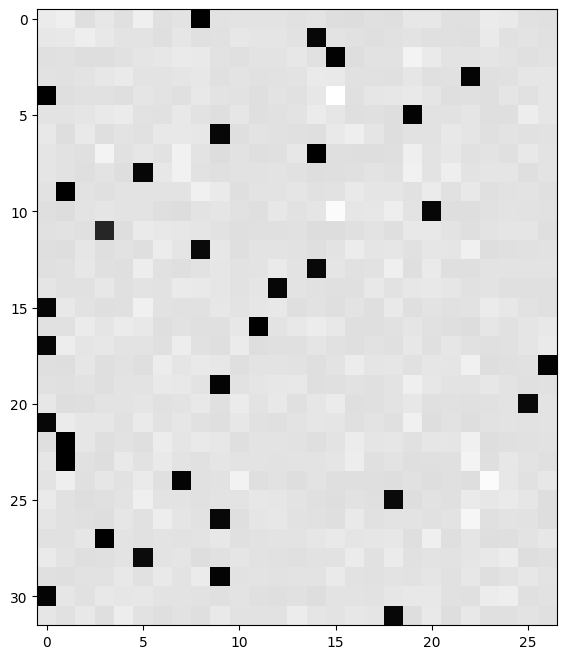

In [33]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray');

## 练习 3 - 简化批归一化

要完成这个挑战，查看批归一化输出的数学表达式，<br>
对其输入求导，简化表达式，然后直接写出来。<br><br>
批归一化论文：[\[Ioffe, Sergey; Szegedy, Christian. 2015\]](https://arxiv.org/abs/1502.03167)

我们想找到一个单一操作来反向传播构成批归一化的整个方程栈。<br>
我们有 `dhpreact`（论文中的 $y_i$），并想从中*高效*地产生 `dhprebn`。

In [34]:
# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


让我们写出批归一化论文中的方程：
$$\mu_B = \frac{1}{m} \sum_{i=1}^m x_i\ \
\sigma_B^2 = \frac{1}{m-1} \sum_{i=1}^m(x_i-\mu_B)^2\ \ \ \ \ \small{(\text{贝塞尔校正})}\ \
\hat{x_i} = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2+\epsilon}}\ \
y_i = \gamma\hat{x_i}+\beta \equiv BN_{\gamma,\beta}(x_i)$$
我们有 $\frac{\partial l}{\partial y_i}$，基于此，我们想要 $\frac{\partial l}{\partial x_i}$。

### 步骤 1

第一部分很直接。<br>
对于 $y_i = \gamma\hat{x_i}+\beta$，我们可以推导出 $\frac{\partial l}{\partial \hat{x_i}} = \frac{\partial l}{\partial y_i} \cdot \gamma$。


### 步骤 2

对于 $\frac{\partial l}{\partial \sigma^2}$，我们必须考虑到 $\hat{x}$ 中存在许多 $\hat{x_i}$。<br>
这些单独的值每一个都依赖于 $\sigma^2$。<br>
"从 $\sigma^2$ 到 $\hat{x}$ 有很多箭头。"

这就是为什么我们需要对所有 $i$ 的 $\hat{x_i}$ 求和。

$$\frac{\partial l}{\partial \sigma^2} = \sum_{i}\left( \frac{\partial l}{\partial \hat{x_i}} \cdot \frac{\partial \hat{x_i}}{\partial \sigma^2}\right) $$

展开这个表达式，我们得到：

$$= \gamma \cdot \sum_i \frac{\partial}{\partial \sigma^2}\begin{bmatrix}(x_i - \mu)(\sigma^2 + \epsilon)^{-1/2}\end{bmatrix} \cdot \frac{\partial l}{\partial y_i}\ \
= \frac{1}{2} \gamma \sum_i (x_i - \mu)(\sigma^2+\epsilon)^{-3/2} \cdot \frac{\partial l}{\partial y_i}$$


### 步骤 3

$\frac{\partial l}{\partial \mu}$ 是什么？<br>
$\mu$ 和 $\hat{x}$ 之间的关系是 $32$ 重的（就像之前 $\sigma^2$ 和 $\hat{x}$ 之间的关系）。<br>
$\mu$ 和 $\sigma^2$ 之间的关系是 $1$ 重的，因为 $\sigma^2$ 只是一个标量（*见上文*）。

所有这 $33$ 个传入梯度需要在 $\mu$ 内求和。

$$\frac{\partial l}{\partial \mu} = \sum_i \left( \frac{\partial l}{\partial \hat{x}} \cdot \frac{\partial \hat{x_i}}{\partial \sigma^2}\right) + \left( \frac{\partial l}{\partial \sigma^2} \cdot \frac{\partial \sigma^2}{\partial \mu}\right)$$

第一部分是 $32$ 重关系。<br>
添加的第二部分是 $1$ 重关系。

### 步骤 4

现在，对于 $x$ 中的每个 $x_i$，发出三条箭头：
- 一条指向 $\mu$ 的箭头
- 一条指向 $\sigma^2$ 的箭头
- 一条指向 $\hat{x}$ 中*每个单独* $\hat{x_i}$ 的箭头

In [35]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# Getting this python code for the above final equation is not easy
dhprebn = bngain * bnvar_inv / n * (n * dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():
  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    # loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, dim=1) # Softmax along the rows of logits
    dlogits[range(n), Yb] -= 1 # At the correct position(s) within dlogits, we need to always subtract a 1
    dlogits /= n               # Scale down gradient by n because of the mean
    # 2nd Linear Layer
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # Tanh
    dhpreact = (1.0 - h**2) * dh
    # Batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain * bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st Linear Layer
    dembcat = dhprebn @ W1.T
    dW1 = dembcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # Embedding Layer
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    # Comment out early breaking below when ready to train full net
    # if i >= 100:
    #   break

12297
      0/ 200000: 3.7918
  10000/ 200000: 2.2118
  20000/ 200000: 2.4945
  30000/ 200000: 2.7126
  40000/ 200000: 2.1289
  50000/ 200000: 2.8434
  60000/ 200000: 2.5684
  70000/ 200000: 2.3247
  80000/ 200000: 2.5403
  90000/ 200000: 2.4744
 100000/ 200000: 2.7280
 110000/ 200000: 3.0945
 120000/ 200000: 2.7420
 130000/ 200000: 2.8820
 140000/ 200000: 2.8666
 150000/ 200000: 2.8361
 160000/ 200000: 2.8772
 170000/ 200000: 2.6707
 180000/ 200000: 2.7903
 190000/ 200000: 2.8445


In [41]:
# useful for checking your gradients

# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [42]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [43]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.8233625888824463
val 2.8218600749969482


In [51]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

ernaaimyaahreelmnd.
ryalaretmrsjejdrleg.
adeeedieliihemy.
realekeiseananarneatzimhlkaa.
n.
sadbvrgahimies.
.
n.
jr.
eelklxnteuoanu.
amnedar.
yirle.
ehs.
laajaysknyaaahya.
nalyaisun.
zajelveuren.
.
.
t.
nsveaoec.


<center>笔记本由 <a href="https://github.com/mk2112" target="_blank">mk2112</a> 编写。</center>